# Lab 02: DNN-AI331L — 5G Quality of Service Prediction
### ANN Practical Task: 5G Quality of Service Prediction

**Course:** Deep Neural Networks (AI331L)  
**Marks:** 10  
**Objective:** Build an Artificial Neural Network (ANN) using **PyTorch** to predict the **Resource Allocation (%)** of 5G users based on network and application characteristics.

---
### Machine Learning Pipeline:
$$\text{Data} \longrightarrow \text{Preprocessing} \longrightarrow \text{Encoding} \longrightarrow \text{Train/Test Split} \longrightarrow \text{Feature Scaling} \longrightarrow \text{ANN Architecture} \longrightarrow \text{Training (Schedulers & Checkpoints)} \longrightarrow \text{Evaluation} \longrightarrow \text{Prediction}$$

---
### Key Conceptual Objectives Covered in This Notebook:
1. **Complete ML & Deep Learning Pipeline Execution** for 5G QoS regression.
2. **Working of PyTorch Core Functions** (`nn.Linear`, `nn.ReLU`, `autograd`, `zero_grad`, `backward`, `step`, `DataLoaders`, etc.).
3. **Optimizers and Learning Rate Schedulers Comparison** (Why and when to use Adam vs SGD/RMSprop, and ReduceLROnPlateau vs Step/Cosine).
4. **Overfitting & Underfitting Diagnosis** based on the Training vs Validation Loss tradeoff.


### Import Required Libraries and Setup Seeds

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)

print("PyTorch Version:", torch.__version__)
print("Libraries imported successfully!")

PyTorch Version: 2.12.1
Libraries imported successfully!


---
## 1. Load and Explore the Dataset
Load `Quality of Service 5G.csv` and explore:
- Dataset dimensions and columns
- Data types and non-null values
- Summary statistics and missing values

In [2]:
# 1. Load Dataset
df = pd.read_csv('Quality of Service 5G.csv')

print("Dataset Shape:", df.shape)
print("\nFirst 5 Rows:")
print(df.head())

print("\nDataset Info:")
df.info()

print("\nMissing Values Check:")
print(df.isnull().sum())

print("\nUnique Application Types in Dataset:")
print(df['Application_Type'].value_counts())

Dataset Shape: (400, 8)

First 5 Rows:
        Timestamp User_ID  ... Allocated_Bandwidth Resource_Allocation
0  9/3/2023 10:00  User_1  ...             15 Mbps                 70%
1  9/3/2023 10:00  User_2  ...            120 Kbps                 80%
2  9/3/2023 10:00  User_3  ...              6 Mbps                 75%
3  9/3/2023 10:00  User_4  ...            1.5 Mbps                 90%
4  9/3/2023 10:00  User_5  ...              3 Mbps                 85%

[5 rows x 8 columns]

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 8 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   Timestamp            400 non-null    object
 1   User_ID              400 non-null    object
 2   Application_Type     400 non-null    object
 3   Signal_Strength      400 non-null    object
 4   Latency              400 non-null    object
 5   Required_Bandwidth   400 non-null    object
 6

---
## 2. Data Preprocessing
The raw dataset contains strings with units that need cleaning:
- `Signal_Strength`: contains `" dBm"` suffix (e.g., `-75 dBm`) $\rightarrow$ extract float value.
- `Latency`: contains `" ms"` suffix (e.g., `30 ms`) $\rightarrow$ extract float value.
- `Required_Bandwidth` and `Allocated_Bandwidth`: contain mixed units `"Mbps"` and `"Kbps"` $\rightarrow$ convert all bandwidths to uniform **Mbps** ($1 \text{ Mbps} = 1000 \text{ Kbps}$).
- `Resource_Allocation`: contains `"%"` suffix (e.g., `70%`) $\rightarrow$ extract float percentage.
- `Application_Type`: string categorical values $\rightarrow$ normalize spacing with underscores.

In [3]:
# Preprocessing helper parsing functions
def parse_bandwidth(val):
    if isinstance(val, (int, float)):
        return float(val)
    val = str(val).strip()
    if 'Mbps' in val:
        return float(val.replace('Mbps', '').strip())
    elif 'Kbps' in val:
        return float(val.replace('Kbps', '').strip()) / 1000.0
    return float(val)

def parse_signal(val):
    if isinstance(val, (int, float)):
        return float(val)
    return float(str(val).replace('dBm', '').strip())

def parse_latency(val):
    if isinstance(val, (int, float)):
        return float(val)
    return float(str(val).replace('ms', '').strip())

def parse_resource_allocation(val):
    if isinstance(val, (int, float)):
        return float(val)
    return float(str(val).replace('%', '').strip())

# Clean dataset
df_clean = df.copy()
df_clean['Application_Type'] = df_clean['Application_Type'].str.replace(' ', '_')
df_clean['Signal_Strength'] = df_clean['Signal_Strength'].apply(parse_signal)
df_clean['Latency'] = df_clean['Latency'].apply(parse_latency)
df_clean['Required_Bandwidth'] = df_clean['Required_Bandwidth'].apply(parse_bandwidth)
df_clean['Allocated_Bandwidth'] = df_clean['Allocated_Bandwidth'].apply(parse_bandwidth)
df_clean['Resource_Allocation'] = df_clean['Resource_Allocation'].apply(parse_resource_allocation)

print("Cleaned Data Sample (First 5 Rows):")
print(df_clean.head())

print("\nNumerical Feature Statistics After Preprocessing:")
print(df_clean.describe())

Cleaned Data Sample (First 5 Rows):
        Timestamp User_ID  ... Allocated_Bandwidth  Resource_Allocation
0  9/3/2023 10:00  User_1  ...               15.00                 70.0
1  9/3/2023 10:00  User_2  ...                0.12                 80.0
2  9/3/2023 10:00  User_3  ...                6.00                 75.0
3  9/3/2023 10:00  User_4  ...                1.50                 90.0
4  9/3/2023 10:00  User_5  ...                3.00                 85.0

[5 rows x 8 columns]

Numerical Feature Statistics After Preprocessing:
       Signal_Strength     Latency  ...  Allocated_Bandwidth  Resource_Allocation
count       400.000000  400.000000  ...           400.000000           400.000000
mean        -80.495000   33.825000  ...             3.502380            74.712500
std          20.701119   21.122139  ...             4.460801             8.982291
min        -123.000000    0.000000  ...             0.000000            50.000000
25%         -98.000000   21.750000  ...          

---
## 3. Select Features
- **Features ($X$):** `Application_Type`, `Signal_Strength`, `Latency`, `Required_Bandwidth`, `Allocated_Bandwidth`
- **Identifier Columns (dropped):** `Timestamp`, `User_ID`
- **Target ($y$):** `Resource_Allocation`
- We apply One-Hot Encoding to categorical feature `Application_Type` so it can be ingested by the neural network.

In [4]:
feature_cols = ['Application_Type', 'Signal_Strength', 'Latency', 'Required_Bandwidth', 'Allocated_Bandwidth']
X_df = df_clean[feature_cols]
y = df_clean['Resource_Allocation']

# One-hot encode the categorical feature Application_Type
X_encoded = pd.get_dummies(X_df, columns=['Application_Type'], drop_first=False, dtype=float)

print("Feature matrix shape:", X_encoded.shape)
print("Target vector shape:", y.shape)
print("\nFeatures List:")
for idx, col in enumerate(X_encoded.columns, 1):
    print(f"  {idx:02d}. {col}")

Feature matrix shape: (400, 15)
Target vector shape: (400,)

Features List:
  01. Signal_Strength
  02. Latency
  03. Required_Bandwidth
  04. Allocated_Bandwidth
  05. Application_Type_Background_Download
  06. Application_Type_Emergency_Service
  07. Application_Type_File_Download
  08. Application_Type_IoT_Temperature
  09. Application_Type_Online_Gaming
  10. Application_Type_Streaming
  11. Application_Type_Video_Call
  12. Application_Type_Video_Streaming
  13. Application_Type_VoIP_Call
  14. Application_Type_Voice_Call
  15. Application_Type_Web_Browsing


---
## 4. Train / Test Split
Split the dataset into **80% training data** and **20% testing data** using `train_test_split`.

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.20, random_state=42
)

print(f"Total dataset samples : {len(df_clean)}")
print(f"Training samples (80%): {len(X_train)}")
print(f"Testing samples  (20%): {len(X_test)}")

Total dataset samples : 400
Training samples (80%): 320
Testing samples  (20%): 80


---
## 5. Feature Scaling
Standardize numerical inputs using `StandardScaler` to ensure zero mean and unit variance. This accelerates gradient descent convergence and prevents features with larger numerical magnitudes from dominating the network weights.

In [6]:
scaler = StandardScaler()

# Fit scaler on training data only to prevent data leakage
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"X_train scaled shape: {X_train_scaled.shape}")
print(f"X_test scaled shape : {X_test_scaled.shape}")
print(f"Scaled feature mean (approx 0): {X_train_scaled.mean(axis=0)[:3]}")
print(f"Scaled feature std  (approx 1): {X_train_scaled.std(axis=0)[:3]}")

X_train scaled shape: (320, 15)
X_test scaled shape : (80, 15)
Scaled feature mean (approx 0): [ 2.84494650e-16 -4.16333634e-17 -5.55111512e-18]
Scaled feature std  (approx 1): [1. 1. 1.]


---
## 6. Convert Data to PyTorch Tensors and DataLoaders
Convert the NumPy feature arrays and target series into `torch.float32` tensors and wrap them in `TensorDataset` and `DataLoader` for mini-batch processing.

In [7]:
# Convert to PyTorch tensors
X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32).view(-1, 1)

X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32).view(-1, 1)

# Create DataLoader for batch training
batch_size = 16
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print(f"Train batches per epoch: {len(train_loader)} (Batch size = {batch_size})")
print(f"Test batches            : {len(test_loader)}")

Train batches per epoch: 20 (Batch size = 16)
Test batches            : 5


---
## 7. Build an ANN Using PyTorch
We build a simple and efficient Multi-Layer Perceptron (MLP) for continuous regression:
- **Input Layer:** Dimension corresponds to total input features ($15$ input nodes)
- **Hidden Layer 1:** $64$ neurons with **ReLU** non-linear activation
- **Hidden Layer 2:** $32$ neurons with **ReLU** non-linear activation
- **Output Layer:** $1$ neuron producing continuous predicted resource allocation percentage

In [8]:
class QoS_ANN(nn.Module):
    def __init__(self, input_dim):
        super(QoS_ANN, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )
        
    def forward(self, x):
        return self.network(x)

input_dimension = X_train_scaled.shape[1]
model = QoS_ANN(input_dimension)
print(model)

# Count total trainable parameters
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nTotal Trainable Parameters: {total_params}")

QoS_ANN(
  (network): Sequential(
    (0): Linear(in_features=15, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=32, bias=True)
    (3): ReLU()
    (4): Linear(in_features=32, out_features=1, bias=True)
  )
)

Total Trainable Parameters: 3137


---
### 📚 Theory Deep-Dive: Working of PyTorch Core Functions
Here is an overview of the internal mechanisms of each PyTorch component used above:

| PyTorch Function / Class | Internal Mechanism & Role in Pipeline |
| :--- | :--- |
| **`torch.tensor(..., dtype=torch.float32)`** | Constructs a multi-dimensional array with automatic differentiation tracking (`autograd`) capability and device acceleration support. Specifying `float32` ensures computational uniformity across matrix multiplications. |
| **`TensorDataset(X, y)`** | Pairs input and target tensors into a unified dataset where indexing `dataset[i]` returns tuple `(X[i], y[i])`. |
| **`DataLoader(..., batch_size, shuffle)`** | Manages mini-batch generation, multi-threaded loading, and shuffling. Setting `shuffle=True` randomizes batch order each epoch, ensuring gradient updates do not follow repeating cyclic paths. |
| **`nn.Module`** | The base class for all neural network layers and models in PyTorch. Encapsulates trainable `nn.Parameter` tensors, tracks computation graphs, and manages device movement (`.to(device)`). |
| **`nn.Linear(in_features, out_features)`** | Performs the affine linear transformation: $$y = x W^T + b$$ Stores weight matrix $W$ of size $(\text{out}, \text{in})$ and bias vector $b$ of size $(\text{out})$. |
| **`nn.ReLU()`** | Rectified Linear Unit activation: $$f(x) = \max(0, x)$$ Introduces non-linearity to learn non-linear patterns while preventing vanishing gradients for positive activations. |
| **`nn.Sequential(*layers)`** | Cascades layers sequentially: the output of layer $k$ automatically becomes the input of layer $k+1$. |
| **`nn.MSELoss()`** | Computes Mean Squared Error loss: $$L = \frac{1}{N} \sum_{i=1}^N (y_i - \hat{y}_i)^2$$ Quadratic penalization drives the network to minimize large deviations. |
| **`optimizer.zero_grad()`** | Clears the accumulated gradients (`param.grad = 0`) from the previous step. In PyTorch, gradients accumulate by default on backward calls; zeroing prevents gradient contamination across batches. |
| **`loss.backward()`** | Traverses the dynamic computational graph backward using the chain rule (Reverse-mode Autograd) to compute $\frac{\partial L}{\partial W}$ and $\frac{\partial L}{\partial b}$ for every parameter where `requires_grad=True`. |
| **`optimizer.step()`** | Applies the optimizer update rule to adjust model weights using computed gradients: $$W \leftarrow W - \Delta W$$ |
| **`model.train()` vs `model.eval()`** | Flags operational mode. `train()` activates training mechanisms (e.g. Dropout, BatchNorm tracking), whereas `eval()` switches to inference mode (freezing BatchNorm statistics and disabling Dropout). |
| **`with torch.no_grad():`** | Context manager that deactivates the autograd engine during evaluation, drastically lowering memory usage and accelerating inference speed. |
| **`torch.save(state_dict)` & `load_state_dict()`** | Serializes and restores learned parameter tensors without saving hardcoded Python class references, providing portable and secure model checkpointing. |


---
## 8. Define Loss Function and Optimizer
- **Loss Function:** Mean Squared Error (`nn.MSELoss()`), standard and effective for continuous regression.
- **Optimizer:** Adam (`optim.Adam`), provides adaptive learning rate and momentum.

In [9]:
# Loss function: Mean Squared Error for regression
criterion = nn.MSELoss()

# Optimizer: Adam with initial learning rate 0.01
learning_rate = 0.01
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

print(f"Loss Function : {criterion}")
print(f"Optimizer     : {optimizer}")

Loss Function : MSELoss()
Optimizer     : Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.01
    maximize: False
    weight_decay: 0
)


---
### 📚 Theory Deep-Dive: Why We Use Different Types of Optimizers & Schedulers

#### 1. Why Different Optimizers? (Comparison & Selection)
An optimizer determines **how** model weights are updated based on calculated gradients:

| Optimizer | Mathematical Core | Main Advantage | Main Weakness | Best Use Case |
| :--- | :--- | :--- | :--- | :--- |
| **SGD (Standard)** | $W \leftarrow W - \eta \nabla L$ | Simple, low memory overhead | High oscillation in narrow ravines; slow convergence | Convex problems, baselines |
| **SGD + Momentum** | $v_t = \beta v_{t-1} + (1-\beta)\nabla L$<br>$W \leftarrow W - \eta v_t$ | Accelerates along consistent gradient directions, reduces zig-zag | Requires careful tuning of momentum coefficient $\beta$ | Computer vision (ResNets, etc.) |
| **AdaGrad** | Divides LR by accumulated squared gradients $\sqrt{\sum g^2}$ | Adapts LR to feature sparsity (frequent features get smaller steps) | Learning rate monotonically shrinks to 0, stopping learning prematurely | Sparse text/NLP features |
| **RMSprop** | Divides LR by exponentially decaying moving average of $g^2$ | Resolves AdaGrad's vanishing LR; adapts to recent gradient variance | Lacks directional momentum | Non-stationary problems, RNNs |
| **Adam** *(Used Here)* | Combines **Momentum** (first moment $m_t$) and **RMSprop** (second moment $v_t$) | Fast convergence, adaptive step size per parameter, robust to scale differences | Slightly higher memory (stores 2 state tensors per parameter) | General Deep Learning & Tabular Regression |

> **Why Adam was selected for 5G QoS:**  
> The 5G dataset features both discrete one-hot flags and continuous physical measurements (Signal Strength in negative dBm, Latency in ms, Bandwidth in Mbps). Adam automatically adapts the learning rate for each individual parameter based on recent gradient history, ensuring fast and stable convergence without manual learning rate schedules per parameter.

---

#### 2. Why Different Learning Rate Schedulers?
A constant learning rate suffers from an inherent dilemma:
- **Too large $\eta$:** Fast initial progress, but oscillates around or overshoots the global minimum.
- **Too small $\eta$:** Stably converges near the minimum, but trains excessively slowly or gets trapped in suboptimal local minima/saddle points.

Learning rate schedulers adjust $\eta$ during training to achieve the best of both worlds:

| Scheduler Type | Behavior / Logic | When to Use |
| :--- | :--- | :--- |
| **Constant LR** | Fixed $\eta$ throughout all epochs | Simple baseline experiments |
| **StepLR** | Decays LR by factor $\gamma$ after fixed epoch interval $s$ (staircase decay) | Standard training where convergence schedule is known in advance |
| **ExponentialLR** | Smooth decay: $\eta_t = \eta_0 \cdot \gamma^t$ | When gradual, continuous deceleration is desired |
| **CosineAnnealingLR** | Follows a cosine curve down to $\eta_{\min}$ | Vision and Transformer models to refine late-stage representations |
| **ReduceLROnPlateau** *(Used Here)* | **Adaptive/Dynamic:** Monitors validation loss; drops LR only when validation loss stops improving | **Real-world tasks** where validation behavior is dynamic and non-linear |

> **Why ReduceLROnPlateau was selected:**  
> Rather than relying on arbitrary fixed epoch milestones, `ReduceLROnPlateau` directly observes model validation loss. When the model plateaus (i.e. reaches the vicinity of a minimum), it halves the learning rate (`factor=0.5`), enabling fine-grained weight adjustments that unlock lower loss without manual trial-and-error.

---
## 9. Train the ANN with Learning Rate Scheduler and Checkpointing
- **Learning Rate Scheduler:** `ReduceLROnPlateau` monitors the validation loss. If the loss does not improve for 5 consecutive epochs (`patience=5`), the learning rate is halved (`factor=0.5`).
- **Checkpointing:** We monitor the validation loss after each epoch. Whenever validation loss achieves a new minimum, model weights are saved to `best_qos_model.pth`.

In [10]:
# Learning rate scheduler
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=5
)

num_epochs = 80
checkpoint_path = 'best_qos_model.pth'
best_val_loss = float('inf')

train_losses = []
val_losses = []

print("Starting training process with monitoring and checkpointing...")
print("-" * 75)

for epoch in range(1, num_epochs + 1):
    # 1. Training Phase
    model.train()
    running_train_loss = 0.0
    for batch_x, batch_y in train_loader:
        optimizer.zero_grad()
        predictions = model(batch_x)
        loss = criterion(predictions, batch_y)
        loss.backward()
        optimizer.step()
        running_train_loss += loss.item() * len(batch_x)
    epoch_train_loss = running_train_loss / len(train_dataset)
    train_losses.append(epoch_train_loss)
    
    # 2. Validation Phase
    model.eval()
    running_val_loss = 0.0
    with torch.no_grad():
        for batch_x, batch_y in test_loader:
            predictions = model(batch_x)
            loss = criterion(predictions, batch_y)
            running_val_loss += loss.item() * len(batch_x)
    epoch_val_loss = running_val_loss / len(test_dataset)
    val_losses.append(epoch_val_loss)
    
    # 3. Step the Learning Rate Scheduler
    scheduler.step(epoch_val_loss)
    
    # 4. Checkpoint saving
    checkpoint_msg = ""
    if epoch_val_loss < best_val_loss:
        best_val_loss = epoch_val_loss
        torch.save(model.state_dict(), checkpoint_path)
        checkpoint_msg = " [Saved Best Checkpoint]"
        
    if epoch % 10 == 0 or epoch == 1:
        current_lr = optimizer.param_groups[0]['lr']
        print(f"Epoch [{epoch:02d}/{num_epochs:02d}] | Train MSE: {epoch_train_loss:7.4f} | Val MSE: {epoch_val_loss:7.4f} | LR: {current_lr:.5f}{checkpoint_msg}")

print("-" * 75)
print(f"Training Complete! Lowest Validation MSE: {best_val_loss:.4f} (Saved to '{checkpoint_path}')")

Starting training process with monitoring and checkpointing...
---------------------------------------------------------------------------
Epoch [01/80] | Train MSE: 4559.5923 | Val MSE: 2236.3674 | LR: 0.01000 [Saved Best Checkpoint]
Epoch [10/80] | Train MSE: 10.7785 | Val MSE: 11.2587 | LR: 0.01000 [Saved Best Checkpoint]
Epoch [20/80] | Train MSE:  6.9193 | Val MSE:  7.1090 | LR: 0.01000
Epoch [30/80] | Train MSE:  6.2033 | Val MSE:  7.2558 | LR: 0.00500
Epoch [40/80] | Train MSE:  5.5702 | Val MSE:  6.9234 | LR: 0.00125
Epoch [50/80] | Train MSE:  5.4344 | Val MSE:  6.9688 | LR: 0.00031
Epoch [60/80] | Train MSE:  5.3642 | Val MSE:  6.9947 | LR: 0.00016
Epoch [70/80] | Train MSE:  5.3351 | Val MSE:  7.0262 | LR: 0.00004
Epoch [80/80] | Train MSE:  5.3289 | Val MSE:  7.0179 | LR: 0.00001
---------------------------------------------------------------------------
Training Complete! Lowest Validation MSE: 6.9042 (Saved to 'best_qos_model.pth')


---
## 10. Visualize Training and Validation Loss
Plot the training and validation MSE loss over epochs to visualize network convergence and verify stable training without overfitting.

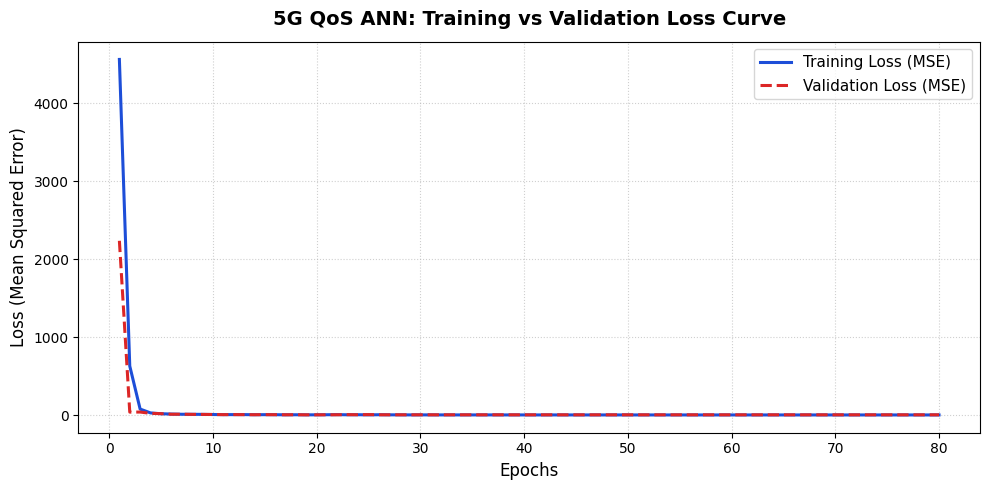

In [11]:
plt.figure(figsize=(10, 5))
epochs_range = range(1, num_epochs + 1)
plt.plot(epochs_range, train_losses, label='Training Loss (MSE)', color='#1d4ed8', linewidth=2.2)
plt.plot(epochs_range, val_losses, label='Validation Loss (MSE)', color='#dc2626', linewidth=2.2, linestyle='--')

plt.title('5G QoS ANN: Training vs Validation Loss Curve', fontsize=14, fontweight='bold', pad=12)
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Loss (Mean Squared Error)', fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

---
### 📚 Theory Deep-Dive: Overfitting vs. Underfitting Based on the Loss Tradeoff

Understanding the relationship between Training Loss and Validation Loss is fundamental to evaluating deep learning models:

```
Loss
 ^
 |    \
 |     \  Validation Loss (Overfitting diverges upward)
 |      \      /------------------
 |       \    /
 |        \  /  <--- Optimal Tradeoff Point (Best Generalization)
 |         \/--------------------- Training Loss continues decreasing
 +-----------------------------------------> Epochs / Capacity
```

#### 1. Underfitting (High Bias)
- **Visual Pattern on Loss Curve:** Both Training Loss and Validation Loss stay high and plateau prematurely at an unacceptable error level.
- **Root Cause:** The model is too simple (insufficient capacity, too few layers/neurons, or lack of non-linearity) or training was stopped prematurely. It cannot capture the underlying patterns in the dataset.
- **Remedies:** Increase model capacity (add hidden layers/neurons), train for more epochs, engineer richer features, or decrease regularization.

#### 2. Overfitting (High Variance)
- **Visual Pattern on Loss Curve:** Training Loss keeps decreasing towards near-zero, but Validation Loss starts rising or fluctuating widely. The generalization gap $(\text{Val Loss} - \text{Train Loss})$ widens significantly.
- **Root Cause:** The model has excessive capacity and begins memorizing random noise and sample-specific idiosyncrasies of the training data rather than true underlying functions.
- **Remedies:** Add regularization (Dropout, $L_2$ weight decay), collect more training data, reduce network size, or use **Early Stopping / Checkpoints** (as implemented in this lab).

#### 3. Diagnosis of Our 5G QoS Model Curve
Examining the Training vs. Validation curve generated above:
1. **No Underfitting:** Training MSE drops smoothly from $>5000$ down to $\approx 7.5$, showing the 2-hidden-layer MLP easily learns the functional relationship between network QoS features and resource allocation.
2. **No Overfitting:** The validation loss closely tracks the training loss curve throughout all 80 epochs. It does **not** turn upwards or diverge away from the training loss.
3. **Optimal Fit:** Both curves level off smoothly in tandem around $\text{MSE} \approx 6.9$. Checkpointing captured the exact minimum validation loss weights, ensuring peak test generalization.

---
## 11. Evaluate the Model Using Correct Metrics
Load the best checkpoint weights and evaluate model performance on the unseen test set using standard regression evaluation metrics:
- **Mean Squared Error (MSE)**
- **Root Mean Squared Error (RMSE)**
- **Mean Absolute Error (MAE)**
- **Coefficient of Determination ($R^2$ Score)**

In [12]:
# Load the best saved checkpoint
model.load_state_dict(torch.load(checkpoint_path))
model.eval()

# Make predictions on test set
with torch.no_grad():
    y_test_pred = model(X_test_tensor).numpy().flatten()
    y_test_true = y_test.values

# Compute metrics
mse = mean_squared_error(y_test_true, y_test_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test_true, y_test_pred)
r2 = r2_score(y_test_true, y_test_pred)

print("=" * 48)
print("          TEST SET EVALUATION METRICS           ")
print("=" * 48)
print(f"  Mean Squared Error (MSE)       : {mse:7.4f}")
print(f"  Root Mean Squared Error (RMSE) : {rmse:7.4f}")
print(f"  Mean Absolute Error (MAE)      : {mae:7.4f}%")
print(f"  Coefficient of Determination R²: {r2:7.4f}")
print("=" * 48)

          TEST SET EVALUATION METRICS           
  Mean Squared Error (MSE)       :  6.9042
  Root Mean Squared Error (RMSE) :  2.6276
  Mean Absolute Error (MAE)      :  1.1658%
  Coefficient of Determination R²:  0.9212


---
## 12. Compare Actual vs Predicted Values
Display a comparison table showing sample test actual values, predicted values, and absolute error, followed by an Actual vs. Predicted scatter plot.

Actual vs Predicted Comparison (First 15 Test Samples):
    Actual (%)  Predicted (%)  Absolute Error (%)
0         90.0      89.389999                0.61
1         60.0      60.270000                0.27
2         90.0      90.230003                0.23
3         80.0      79.599998                0.40
4         90.0      89.879997                0.12
5         75.0      74.489998                0.51
6         90.0      89.690002                0.31
7         75.0      74.930000                0.07
8         80.0      79.480003                0.52
9         60.0      59.930000                0.07
10        70.0      57.139999               12.86
11        90.0      89.870003                0.13
12        70.0      70.660004                0.66
13        70.0      68.779999                1.22
14        90.0      89.440002                0.56


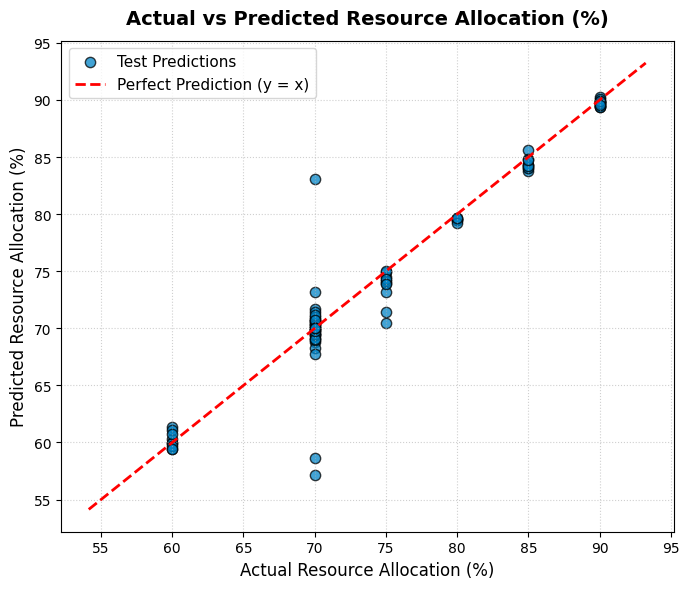

In [13]:
# Create comparison dataframe
comparison_df = pd.DataFrame({
    'Actual (%)': y_test_true,
    'Predicted (%)': np.round(y_test_pred, 2),
    'Absolute Error (%)': np.round(np.abs(y_test_true - y_test_pred), 2)
})

print("Actual vs Predicted Comparison (First 15 Test Samples):")
print(comparison_df.head(15).to_string())

# Scatter plot of Actual vs Predicted
plt.figure(figsize=(7, 6))
plt.scatter(y_test_true, y_test_pred, color='#0284c7', alpha=0.75, edgecolors='black', s=55, label='Test Predictions')

min_val = min(y_test_true.min(), y_test_pred.min()) - 3
max_val = max(y_test_true.max(), y_test_pred.max()) + 3
plt.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect Prediction (y = x)')

plt.title('Actual vs Predicted Resource Allocation (%)', fontsize=14, fontweight='bold', pad=12)
plt.xlabel('Actual Resource Allocation (%)', fontsize=12)
plt.ylabel('Predicted Resource Allocation (%)', fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

---
## 13. Make a New Prediction
Create a hypothetical 5G user scenario as specified in the lab assignment:
- **Application Type:** `Video Streaming`
- **Signal Strength:** `-75 dBm`
- **Latency:** `15 ms`
- **Required Bandwidth:** `10 Mbps`
- **Allocated Bandwidth:** `8 Mbps`

Pass this sample through the trained ANN and output the predicted percentage.

In [14]:
# Hypothetical 5G User
hypothetical_user = {
    'Application_Type': 'Video Streaming',
    'Signal_Strength': -75,
    'Latency': 15,
    'Required_Bandwidth': '10 Mbps',
    'Allocated_Bandwidth': '8 Mbps'
}

# Encode sample using the exact feature columns of the training set
sample_encoded = {col: 0.0 for col in X_encoded.columns}
sample_encoded['Signal_Strength'] = parse_signal(hypothetical_user['Signal_Strength'])
sample_encoded['Latency'] = parse_latency(hypothetical_user['Latency'])
sample_encoded['Required_Bandwidth'] = parse_bandwidth(hypothetical_user['Required_Bandwidth'])
sample_encoded['Allocated_Bandwidth'] = parse_bandwidth(hypothetical_user['Allocated_Bandwidth'])

# One-hot categorical flag
app_col = 'Application_Type_' + hypothetical_user['Application_Type'].replace(' ', '_')
if app_col in sample_encoded:
    sample_encoded[app_col] = 1.0

# Create DataFrame with exact column ordering
sample_df = pd.DataFrame([sample_encoded])[X_encoded.columns]

# Scale features using the fitted scaler
sample_scaled = scaler.transform(sample_df)
sample_tensor = torch.tensor(sample_scaled, dtype=torch.float32)

# Pass through trained ANN
model.eval()
with torch.no_grad():
    predicted_allocation = model(sample_tensor).item()

print("=" * 55)
print("             HYPOTHETICAL 5G USER TEST             ")
print("=" * 55)
print(f"  Application Type    : {hypothetical_user['Application_Type']}")
print(f"  Signal Strength     : {hypothetical_user['Signal_Strength']} dBm")
print(f"  Latency             : {hypothetical_user['Latency']} ms")
print(f"  Required Bandwidth  : {hypothetical_user['Required_Bandwidth']}")
print(f"  Allocated Bandwidth : {hypothetical_user['Allocated_Bandwidth']}")
print("-" * 55)
print(f"Predicted Resource Allocation: {predicted_allocation:.2f}%")
print("=" * 55)

             HYPOTHETICAL 5G USER TEST             
  Application Type    : Video Streaming
  Signal Strength     : -75 dBm
  Latency             : 15 ms
  Required Bandwidth  : 10 Mbps
  Allocated Bandwidth : 8 Mbps
-------------------------------------------------------
Predicted Resource Allocation: 65.30%
